# Modelo VGG 4


En este notebook probamos a ejecutar el modelo VGG sin el 4º bloque, 
partiendo de los pesos de `modelo_vgg_2`.

Para reutilizar los pesos entre dos arquitecturas distintas sin que 
produzca un error, cargamos primero un modelo idéntico al de 
`modelo_vgg_2` e inicializamos sus pesos. Después creamos el nuevo 
modelo con la arquitectura reducida y transferimos únicamente los pesos 
de las capas cuyos nombres coinciden en ambos modelos.

Este enfoque es una forma de **transfer learning interno**: en lugar de 
inicializar los pesos aleatoriamente, el modelo parte de pesos ya 
entrenados en el mismo problema, lo que en principio debería acelerar 
la convergencia y mejorar el resultado final.


In [1]:
# El siguiente codigo sirve para que el notebook funcione igual en colab o en local
# Si se ejecuta en la nube se cargue el repositorio, de esta forma se pueda acceder 
# a los diferentes archivos que necesite para su ejecución de forma automatica
import sys
import os

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    repo_path = '/content/eye_diseases_classification_trabajo_DL'
    if not os.path.exists(repo_path):
        !git clone https://github.com/ropas5/eye_diseases_classification_trabajo_DL.git
        sys.path.append('/content/eye_diseases_classification_trabajo_DL/notebooks')
    # from google.colab import userdata
    # userdata.get('kaggle')
    else:
        print("Repo ya existe, actualizando")
        %cd /content/eye_diseases_classification_trabajo_DL/notebooks
        !git pull 
        
    #Cargamos el kaggle.json
    import ipywidgets as widgets
    from IPython.display import display
    
    uploader = widgets.FileUpload(accept='.json')
    display(uploader)
else:
    print("Ejecución en local")
    uploader = None

Ejecución en local


### Impotacion y preprocesado de datos

In [2]:
from importacion_preprocesado import descarga_y_carga_de_datos, preprocesamiento


tamany_img = (128,128) # tamaño reducido para colab, porque si no supera la ram
X, y = descarga_y_carga_de_datos(target_size=tamany_img, uploader= uploader)

X_train, X_val, X_test, y_train, y_val, y_test = preprocesamiento(X, y)

Dataset ya existe, solo se van a cargar las imágenes.
X shape: (4217, 128, 128, 3) y shape: (4217,)


### Modelo

In [25]:
# Importar el modelo
import sys
sys.path.append('../')

import importlib
import models.complejo_vgg_3
importlib.reload(models.complejo_vgg_3) # recargamos el cache para tener la ultima versión del modelo 
from models.complejo_vgg_3 import create_model

# Crear el modelo
model = create_model(input_shape=(128,128,3), num_classes=4, l_rate=0.0001, bloque = "block3_pool")

In [26]:
model.summary(expand_nested=True)

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ functional_7 (Functional)       │ (None, 16, 16, 256)    │     1,735,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ input_layer_6 (InputLayer) │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ block1_conv1 (Conv2D)      │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ block1_conv2 (Conv2D)      │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ block1_pool (MaxPooling2D) │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ block2_conv1 (Conv2D)      │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ block2_conv2 (Conv2D)      │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ block2_pool (MaxPooling2D) │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ block3_conv1 (Conv2D)      │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ block3_conv2 (Conv2D)      │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ block3_conv3 (Conv2D)      │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ block3_pool (MaxPooling2D) │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,999,428 (7.63 MB)

 Trainable params: 1,999,428 (7.63 MB)

 Non-trainable params: 0 (0.00 B)

In [27]:
hist = model.fit(X_train, y_train, validation_data= (X_val, y_val), epochs= 40) 

Epoch 1/40
80/80 ━━━━━━━━━━━━━━━━━━━━ 157s 2s/step - accuracy: 0.5425 - loss: 1.0305 - val_accuracy: 0.7536 - val_loss: 0.6793
Epoch 2/40
80/80 ━━━━━━━━━━━━━━━━━━━━ 143s 2s/step - accuracy: 0.7232 - loss: 0.6958 - val_accuracy: 0.8104 - val_loss: 0.4696
Epoch 3/40
80/80 ━━━━━━━━━━━━━━━━━━━━ 149s 2s/step - accuracy: 0.7900 - loss: 0.5345 - val_accuracy: 0.8507 - val_loss: 0.3937
Epoch 4/40
80/80 ━━━━━━━━━━━━━━━━━━━━ 149s 2s/step - accuracy: 0.8264 - loss: 0.4335 - val_accuracy: 0.8566 - val_loss: 0.3572
Epoch 5/40
80/80 ━━━━━━━━━━━━━━━━━━━━ 147s 2s/step - accuracy: 0.8695 - loss: 0.3443 - val_accuracy: 0.8685 - val_loss: 0.3334
Epoch 6/40
80/80 ━━━━━━━━━━━━━━━━━━━━ 147s 2s/step - accuracy: 0.8699 - loss: 0.3439 - val_accuracy: 0.8839 - val_loss: 0.3088
Epoch 7/40
80/80 ━━━━━━━━━━━━━━━━━━━━ 147s 2s/step - accuracy: 0.8905 - loss: 0.2958 - val_accuracy: 0.8993 - val_loss: 0.2747
Epoch 8/40
80/80 ━━━━━━━━━━━━━━━━━━━━ 147s 2s/step - accuracy: 0.8988 - loss: 0.2895 - val_accuracy: 0.9017 - v

### Resultados

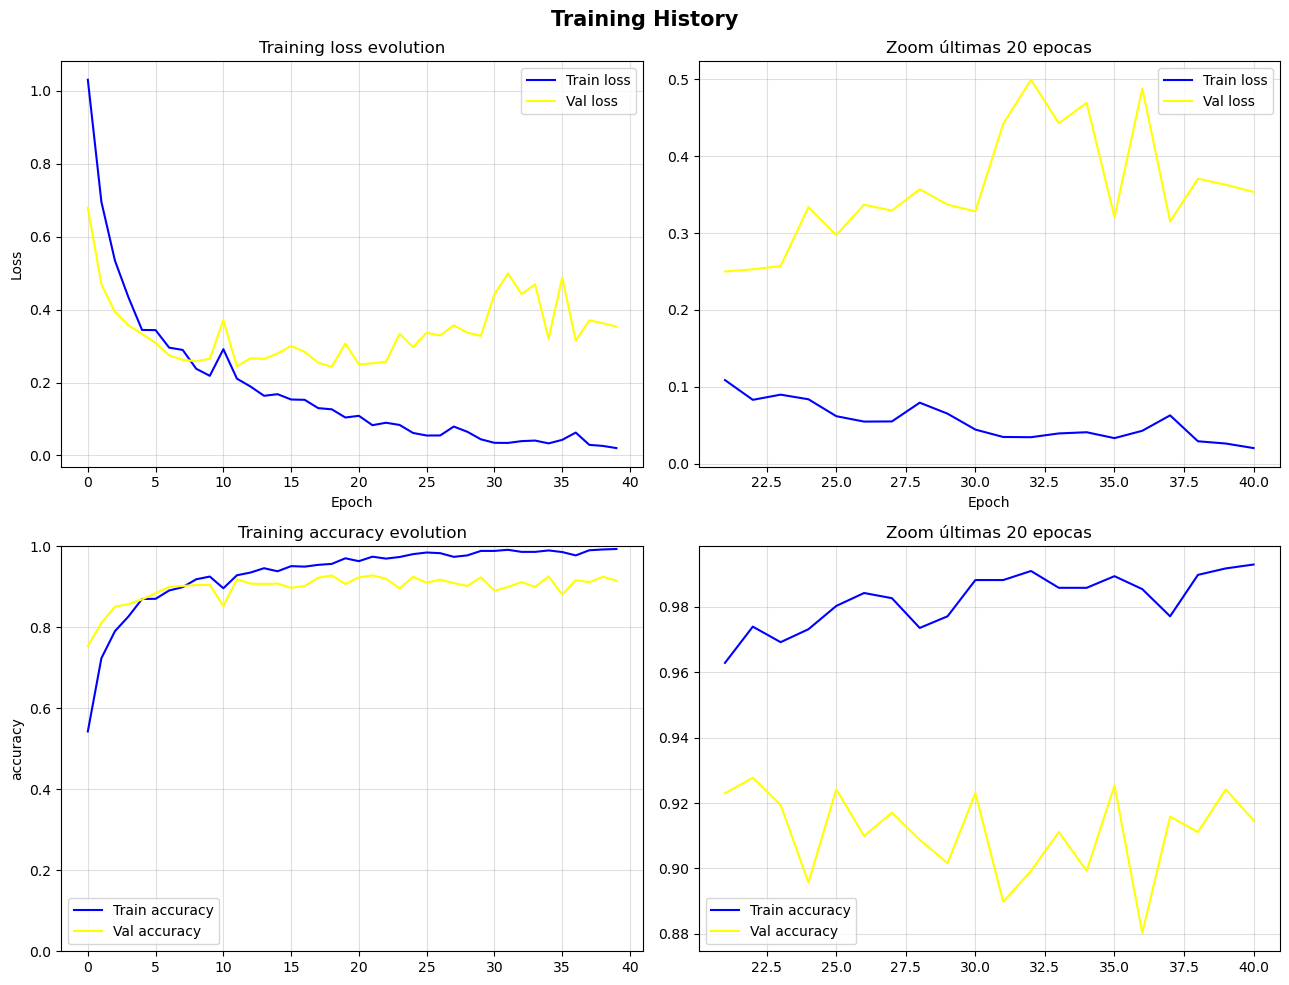

In [28]:
import matplotlib.pyplot as plt
import numpy as np


# número de épocas para el zoom
zoom_epochs = 20

loss = hist.history['loss']
val_loss = hist.history['val_loss']
acc = hist.history["accuracy"]
val_acc = hist.history["val_accuracy"]

epochs = range(1, len(loss) + 1)

fig, ax = plt.subplots(2, 2, figsize=(13,10))
ax  = ax.flatten()
fig.suptitle('Training History', fontsize=15, fontweight='bold')

# Visualizacion evolucion loss durante el entrenamiento
ax[0].plot( loss, label='Train loss', color = "blue")
ax[0].plot( val_loss, label='Val loss', color= "yellow")
ax[0].set_title('Training loss evolution')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[0].grid(True, alpha = 0.4)
ax[0].legend()

# Zoom últimas épocas
ax[1].plot(epochs[-zoom_epochs:], loss[-zoom_epochs:], label='Train loss', color = "blue")
ax[1].plot(epochs[-zoom_epochs:], val_loss[-zoom_epochs:], label='Val loss', color= "yellow")
ax[1].set_title(f'Zoom últimas {zoom_epochs} epocas')
ax[1].set_xlabel('Epoch')
ax[1].grid(True, alpha = 0.4)
ax[1].legend()

# Visualizacion de accuracy durante el entrenamiento
ax[2].plot( acc, label='Train accuracy', color = "blue")
ax[2].plot( val_acc, label='Val accuracy', color= "yellow")
ax[2].grid(True, alpha = 0.4)
ax[2].set_ylim(0,1)
ax[2].set_title('Training accuracy evolution')
ax[2].set_ylabel('accuracy')
ax[2].legend()

# Zoom últimas épocas
ax[3].plot(epochs[-zoom_epochs:], acc[-zoom_epochs:], label='Train accuracy', color = "blue")
ax[3].plot(epochs[-zoom_epochs:], val_acc[-zoom_epochs:], label='Val accuracy', color= "yellow")
ax[3].set_title(f'Zoom últimas {zoom_epochs} epocas')
ax[3].grid(True, alpha = 0.4)
ax[3].legend()

plt.tight_layout()
plt.show()

In [29]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

datasets = {
    "Train": (X_train, y_train),
    "Val": (X_val, y_val),
    "Test": (X_test, y_test)
}

def evaluate(model, X, y):
    #Convertir a enteros
    y_true = np.argmax(y, axis=1)

    y_pred_probs = model.predict(X)
    y_pred = np.argmax(y_pred_probs, axis=1)

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="weighted")
    return acc, f1


def crear_df_metricas(model, datasets):
    results = {}
    for split_name, (X, y) in datasets.items():
        acc, f1 = evaluate(model, X, y)
        results[split_name] = [acc, f1]
    
    df = pd.DataFrame(results, index=["Accuracy", "F1"])
    return df

In [30]:
df = crear_df_metricas(model, datasets)
print(df.round(3))

80/80 ━━━━━━━━━━━━━━━━━━━━ 33s 412ms/step
27/27 ━━━━━━━━━━━━━━━━━━━━ 11s 403ms/step
27/27 ━━━━━━━━━━━━━━━━━━━━ 11s 400ms/step
          Train    Val   Test
Accuracy  0.998  0.915  0.927
F1        0.998  0.914  0.926


In [31]:
def plot_barra(metrica, titulo, color):

    plt.figure(figsize=(6,4))
    bars = plt.bar(metrica.index, metrica.values, color=color)
    plt.bar_label(bars)
    plt.title(f"{titulo}: Train vs Validation vs Test")
    plt.ylabel(titulo)
    plt.ylim(0,1)
    plt.grid(axis='y', linestyle='--')
    plt.show()


def plots_metricas(df):
    #Extraemos la fila
    accuracy = df.loc["Accuracy"]
    f1 = df.loc["F1"]

    #Grafico de Accuracy
    plot_barra(accuracy, titulo = "Accuracy", color="blue")

    #Grafico de 
    plot_barra(f1, titulo ="F1", color = "red")

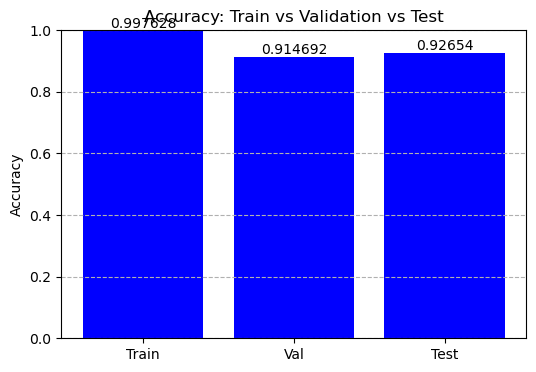

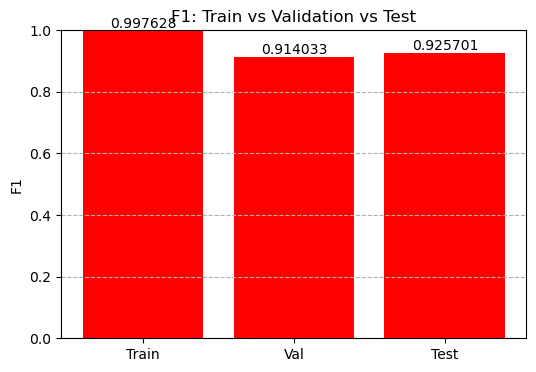

In [32]:
plots_metricas(df)

27/27 ━━━━━━━━━━━━━━━━━━━━ 11s 414ms/step


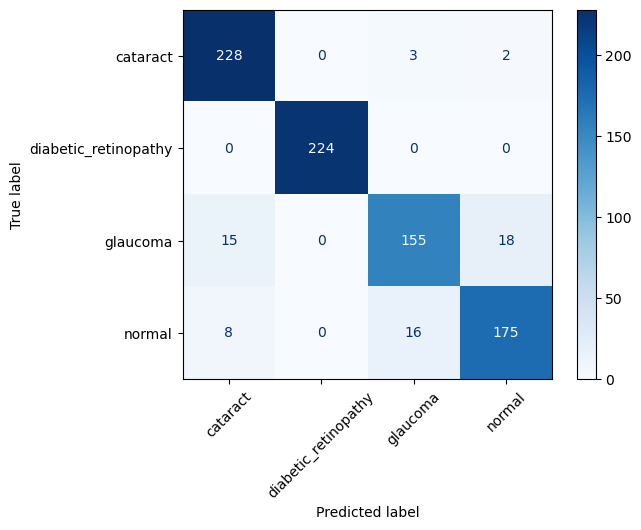

In [33]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_true = np.argmax(y_test, axis=1)
y_pred = np.argmax(model.predict(X_test), axis=1)

cm = confusion_matrix(y_true, y_pred)
ConfusionMatrixDisplay(cm,  
                    display_labels= ["cataract", "diabetic_retinopathy", "glaucoma", "normal"]
                    ).plot(cmap="Blues", xticks_rotation= 45.0)

In [34]:
from sklearn.metrics import precision_recall_fscore_support

def per_class_table(model, datasets):
    # class_names: lista con nombres de las clases en el orden de los índices (opcional)
    class_names = ["cataract", "diabetic_retinopathy", "glaucoma", "normal"]  

    splits = list(datasets.keys())
    # identificamos número de clases desde los datos si no dan nombres
    sample_X, sample_y = next(iter(datasets.values()))
    n_classes = np.argmax(sample_y, axis=1).max() + 1

    # DataFrame con index = clases y columnas por split/metric
    cols = []
    for s in splits:
        cols += [f"{s}_Accuracy", f"{s}_F1"]
    df = pd.DataFrame(index=class_names, columns=cols, dtype=float)

    for split in splits:
        X, y = datasets[split]
        y_true = np.argmax(y, axis=1)
        y_pred = np.argmax(model.predict(X), axis=1)

        # precision, recall, f1 por clase
        precision, recall, f1, support = precision_recall_fscore_support(
            y_true, y_pred, labels=np.arange(n_classes), zero_division=0
        )
        # Aquí definimos "Accuracy" por clase como recall (TP / nº verdaderos de la clase)
        for i, cls in enumerate(class_names):
            df.loc[cls, f"{split}_Accuracy"] = recall[i]
            df.loc[cls, f"{split}_F1"] = f1[i]

    return df

In [24]:
df_per_class = per_class_table(model, datasets)
print(df_per_class.round(3))

80/80 ━━━━━━━━━━━━━━━━━━━━ 32s 405ms/step
27/27 ━━━━━━━━━━━━━━━━━━━━ 10s 374ms/step
27/27 ━━━━━━━━━━━━━━━━━━━━ 10s 369ms/step
                      Train_Accuracy  Train_F1  Val_Accuracy  Val_F1  \
cataract                       0.650     0.618         0.704   0.633   
diabetic_retinopathy           0.935     0.959         0.905   0.941   
glaucoma                       0.287     0.405         0.262   0.368   
normal                         0.856     0.682         0.833   0.695   

                      Test_Accuracy  Test_F1  
cataract                      0.648    0.633  
diabetic_retinopathy          0.920    0.943  
glaucoma                      0.277    0.395  
normal                        0.849    0.661  


In [ ]:

MODEL_NAME = "modelo_vgg_4"          
EPOCHS     = len(hist.epoch)
results = {
    "modelo":         MODEL_NAME,
    "epochs":         EPOCHS,
    "Train Accuracy": df.loc["Accuracy", "Train"],
    "Val Accuracy":   df.loc["Accuracy", "Val"],
    "Test Accuracy":  df.loc["Accuracy", "Test"],
    "Train F1":       df.loc["F1", "Train"],
    "Val F1":         df.loc["F1", "Val"],
    "Test F1":        df.loc["F1", "Test"],

}

# Ruta del CSV
CSV_PATH = "../data/processed/model_results.csv"

if os.path.exists(CSV_PATH):
    df = pd.read_csv(CSV_PATH)
    df = pd.concat([df, pd.DataFrame([results])], ignore_index=True)
else:
    df = pd.DataFrame([results])

df.to_csv(CSV_PATH, index=False)

In [ ]:
df